In [7]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import shap
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('creditcard.csv')
X = df.drop(['Class'],axis=1)
y = df['Class']

In [9]:
train, test, labels_train, labels_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [10]:
print(train.head())

            Time        V1        V2        V3        V4        V5        V6  \
44828    42101.0 -0.557458  1.231524  0.573268 -0.263955  0.946120 -1.203171   
221877  142733.0 -0.344935  1.385742  0.686680  1.035083  0.256868 -0.460239   
278826  168463.0 -2.638648  0.975973  0.897377  0.156363  0.096289  0.208338   
149792   91957.0 -0.036151  1.360794 -0.991409  1.003604  0.865763 -0.693477   
226041  144480.0  2.143097 -1.129054 -0.673094 -1.093833 -0.882792  0.115427   

              V7        V8        V9  ...       V20       V21       V22  \
44828   1.057426 -0.130107 -1.042645  ... -0.012924  0.025811  0.023363   
221877  0.963755 -0.294085 -0.565671  ...  0.385026 -0.211719 -0.288454   
278826 -0.150398  0.298436  0.245605  ... -0.772491 -0.117961 -0.781257   
149792  0.926102  0.141968  0.198633  ... -0.339327  0.225501  0.767630   
226041 -1.267968  0.267143  0.143981  ... -0.118375 -0.041227 -0.264483   

             V23       V24       V25       V26       V27       V28  

In [11]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(train, labels_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
y_pred = rf.predict(test)
print("Accuracy: ", accuracy_score(labels_test, y_pred))

Accuracy:  0.9995611109160493


In [13]:
#We only care about the lines of data with fraudolent transactions, therefore we will isolate and explain only those
fraud_list = [row for index, row in test.iterrows() if labels_test[index] == 1]

frauds = pd.DataFrame(fraud_list)

fraudolent_tran = frauds.iloc[[0]]

In [14]:
explainer = shap.KernelExplainer(rf.predict, shap.kmeans(train, 10))
shap_values = explainer(fraudolent_tran)

100%|██████████| 1/1 [00:00<00:00,  6.26it/s]



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


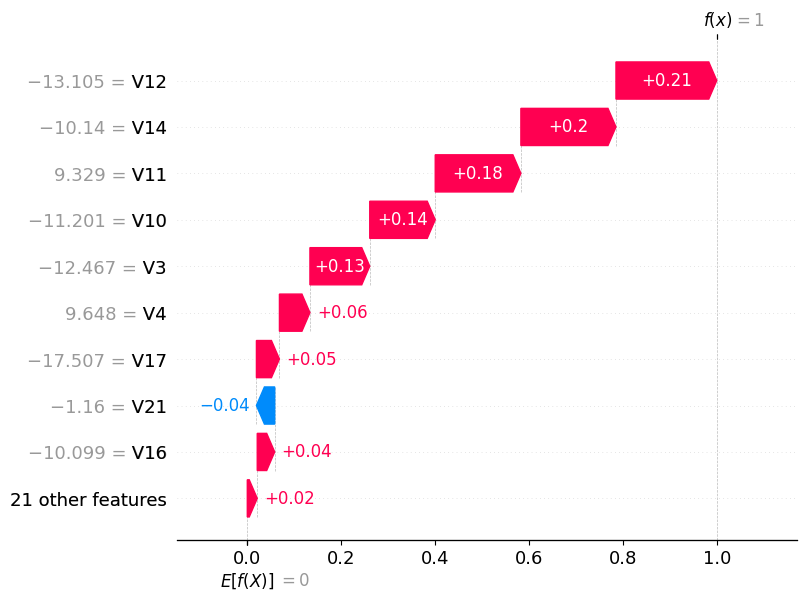

In [15]:
%pip install matplotlib
import matplotlib.pyplot as plt
shap.plots.waterfall(shap_values[0])
plt.show()